# COMP5310 Assignment 1 Data Readiness

## NSW Train Occupancy

This notebook prepares the NSW Train Occupancy dataset for further analysis in Assignment 2.

The purpose of this notebook is to:
1. audit the dataset for data-quality issues;
2. document the variables retained for analysis;
3. identify missing values, duplicates, invalid values and unusual ranges;
4. check for potential target leakage;
5. apply justified and reproducible cleaning steps; and
6. save the final cleaned dataset as a CSV file.

The analysis focuses on supporting a transport operations team in understanding train crowding patterns and opportunities for improved service planning.

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("../data/raw/train_occupancy.csv")

train_df.head()

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
0,9,Miranda,2017-01-10 00:18:17,2017-01-10 00:19:04,Down,620S,Illawarra,Central,Cronulla,T,18,00:15-00:29,MANY_SEATS_AVAILABLE,Low: 0-399
1,13,Beecroft,2017-01-13 08:05:59,2017-01-13 08:06:56,Down,152C,North via Macquarie Park,Central,Hornsby,A,16,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
2,12,Arncliffe,2017-01-12 07:22:51,2017-01-12 07:23:36,Down,607B,Illawarra,Central,Waterfall,T,6,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
3,13,Dulwich Hill,2017-01-13 07:20:39,2017-01-13 07:21:53,Down,58-F,Bankstown,Central,Birrong,A,7,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
4,11,Belmore,2017-01-11 18:38:28,2017-01-11 18:39:07,Up,33-P,Bankstown,Birrong,Central,K,7,18:30-18:44,MANY_SEATS_AVAILABLE,Low: 0-399


In [3]:
print("DATASET SHAPE")
print(train_df.shape)

print("\nDATA TYPES")
print(train_df.dtypes)

print("\nCOLUMN NAMES")
print(train_df.columns.tolist())

DATASET SHAPE
(50250, 14)

DATA TYPES
day                              int64
Actual.Stop.Station                str
Actual.Station.Arrv.Time           str
Actual.Station.Dprt.Time           str
Segment.Direction                  str
Trip.Name                          str
Service.Line                       str
Orig..Station                      str
Dest..Station                      str
Leading.Set.Type                   str
Node.Seq.Order                   int64
Actual.Station.Dprt.Time.Band      str
Occupancy Status                   str
Occupancy Range                    str
dtype: object

COLUMN NAMES
['day', 'Actual.Stop.Station', 'Actual.Station.Arrv.Time', 'Actual.Station.Dprt.Time', 'Segment.Direction', 'Trip.Name', 'Service.Line', 'Orig..Station', 'Dest..Station', 'Leading.Set.Type', 'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status', 'Occupancy Range']


In [4]:
missing = pd.DataFrame({
    "Missing_Count": train_df.isna().sum(),
    "Missing_Percent": train_df.isna().mean() * 100
})

missing = missing.sort_values("Missing_Count", ascending=False)

missing

,Missing_Count,Missing_Percent
Orig..Station,80,0.159204
Segment.Direction,78,0.155224
Leading.Set.Type,77,0.153234
Actual.Stop.Station,74,0.147264
Occupancy Status,73,0.145274
Dest..Station,63,0.125373
Service.Line,59,0.117413
Actual.Station.Dprt.Time,11,0.021891
Actual.Station.Arrv.Time,7,0.013930
day,0,0.000000


In [7]:
duplicate_count = train_df.duplicated().sum()
duplicate_percent = train_df.duplicated().mean() * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percent)

Duplicate rows: 250
Duplicate percentage: 0.4975124378109453


In [8]:
categorical_cols = [
    "Segment.Direction",
    "Service.Line",
    "Leading.Set.Type",
    "Actual.Station.Dprt.Time.Band",
    "Occupancy Status",
    "Occupancy Range"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(train_df[col].value_counts(dropna=False))


--- Segment.Direction ---
Segment.Direction
Up       25197
Down     24817
Up          80
Down        78
NaN         78
Name: count, dtype: int64

--- Service.Line ---
Service.Line
Illawarra                    7587
West                         6261
North Shore                  4818
Airport                      4590
Bankstown                    4154
South                        3646
City Circle                  3197
North  via Macquarie Park    3115
North                        2781
Eastern Suburbs              2277
Inner West                   2205
North  via  Strathfield      1718
Hunter Valley                1089
Cumberland                   1053
Olympic Park West/South       526
Carlingford Shuttle           298
Illawarra to Sydney           191
North Coast                   158
East Hills                    152
South Coast                   142
Port Kembla                   136
NaN                            59
NORTH SHORE                    18
AIRPORT                        17
cit

In [9]:
numeric_cols = ["day", "Node.Seq.Order"]

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(train_df[col].describe())
    print("Unique values:", sorted(train_df[col].dropna().unique())[:20])


--- day ---
count    50250.000000
mean        12.805075
std          2.034840
min          9.000000
25%         11.000000
50%         13.000000
75%         15.000000
max         16.000000
Name: day, dtype: float64
Unique values: [np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

--- Node.Seq.Order ---
count    50250.000000
mean         8.888438
std          6.047581
min          1.000000
25%          4.000000
50%          8.000000
75%         13.000000
max         38.000000
Name: Node.Seq.Order, dtype: float64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [10]:
time_cols = [
    "Actual.Station.Arrv.Time",
    "Actual.Station.Dprt.Time"
]

for col in time_cols:
    print(f"\n--- {col} ---")
    print(train_df[col].head(10))
    print("Missing:", train_df[col].isna().sum())


--- Actual.Station.Arrv.Time ---
0    2017-01-10 00:18:17
1    2017-01-13 08:05:59
2    2017-01-12 07:22:51
3    2017-01-13 07:20:39
4    2017-01-11 18:38:28
5    2017-01-12 18:57:07
6    2017-01-10 14:10:29
7    2017-01-13 06:49:53
8    2017-01-12 07:49:30
9    2017-01-15 11:08:04
Name: Actual.Station.Arrv.Time, dtype: str
Missing: 7

--- Actual.Station.Dprt.Time ---
0    2017-01-10 00:19:04
1    2017-01-13 08:06:56
2    2017-01-12 07:23:36
3    2017-01-13 07:21:53
4    2017-01-11 18:39:07
5    2017-01-12 18:57:40
6    2017-01-10 14:11:20
7    2017-01-13 06:51:05
8    2017-01-12 07:50:11
9    2017-01-15 11:08:55
Name: Actual.Station.Dprt.Time, dtype: str
Missing: 11


In [ ]:
print("Segment.Direction values:")
for value in train_df["Segment.Direction"].dropna().unique():
    print(repr(value)) #repr to show hidden characters like spaces or newlines such that they can be cleaned later

Segment.Direction values:
'Down'
'Up'
'Up '
'Down '


In [12]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    
    values = train_df[col].dropna().unique()
    
    for value in values:
        print(repr(value))


--- Segment.Direction ---
'Down'
'Up'
'Up '
'Down '

--- Service.Line ---
'Illawarra'
'North  via Macquarie Park'
'Bankstown'
'City Circle'
'Eastern Suburbs'
'West'
'Airport'
'North Shore'
'Inner West'
'South'
'North  via  Strathfield'
'North'
'Hunter Valley'
'East Hills'
'Carlingford Shuttle'
'North Coast'
'Port Kembla'
'AIRPORT'
'Illawarra to Sydney'
'Olympic Park West/South'
'Cumberland'
'NORTH SHORE'
'South Coast'
'south coast'
'north coast'
'EASTERN SUBURBS'
'Hunter Valley '
'Cenoral Coast'
'city circle'
'Central Coast'

--- Leading.Set.Type ---
'T'
'A'
'K'
'M'
'H'
'V'
'J'
'N'
'S'
'C'

--- Actual.Station.Dprt.Time.Band ---
'00:15-00:29'
'08:00-08:14'
'07:15-07:29'
'18:30-18:44'
'18:45-18:59'
'14:00-14:14'
'06:45-06:59'
'07:45-07:59'
'11:00-11:14'
'20:15-20:29'
'18:15-18:29'
'17:45-17:59'
'19:00-19:14'
'21:15-21:29'
'17:30-17:44'
'20:00-20:14'
'22:30-22:44'
'08:30-08:44'
'11:30-11:44'
'08:45-08:59'
'23:30-23:44'
'17:15-17:29'
'20:45-20:59'
'22:15-22:29'
'05:15-05:29'
'16:30-16:44'

In [ ]:
for col in categorical_cols:
    train_df[col] = train_df[col].str.strip() #remove leading and trailing whitespace characters

In [ ]:
print(train_df["Segment.Direction"].value_counts(dropna=False)) #combining up and down into 2 categories

Segment.Direction
Up      25277
Down    24895
NaN        78
Name: count, dtype: int64


In [16]:
print("OCCUPANCY STATUS")
print(train_df["Occupancy Status"].value_counts(dropna=False))

print("\nOCCUPANCY RANGE")
print(train_df["Occupancy Range"].value_counts(dropna=False))

OCCUPANCY STATUS
Occupancy Status
MANY_SEATS_AVAILABLE    48008
FEW_SEATS_AVAILABLE      1596
STANDING_ROOM_ONLY        398
MANY_SEATSAVAILABLE       165
NaN                        73
few_seats_available         8
VTANDING_ROOM_ONLY          2
Name: count, dtype: int64

OCCUPANCY RANGE
Occupancy Range
Low: 0-399         45932
Medium: 400-799     3556
High: 800+           762
Name: count, dtype: int64


In [ ]:
train_df["Occupancy Status"] = train_df["Occupancy Status"].replace({
    "MANY_SEATSAVAILABLE": "MANY_SEATS_AVAILABLE",
    "few_seats_available": "FEW_SEATS_AVAILABLE",
    "VTANDING_ROOM_ONLY": "STANDING_ROOM_ONLY"
})
#making the occupancy status values consistent
print(train_df["Occupancy Status"].value_counts(dropna=False))

Occupancy Status
MANY_SEATS_AVAILABLE    48173
FEW_SEATS_AVAILABLE      1604
STANDING_ROOM_ONLY        400
NaN                        73
Name: count, dtype: int64


In [18]:
missing_status = train_df[train_df["Occupancy Status"].isna()]

print("Number of missing Occupancy Status rows:", len(missing_status))
missing_status

Number of missing Occupancy Status rows: 73


,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
485,13,Kogarah,2017-01-13 09:26:21,2017-01-13 09:27:03,Down,606D,Illawarra,Central,Hurstville,T,9,09:15-09:29,NaN,Low: 0-399
575,16,Strathfield,2017-01-16 10:21:56,2017-01-16 10:22:54,Down,187E,West,Central,Penrith,A,3,10:15-10:29,NaN,Low: 0-399
1223,13,Mount Druitt,2017-01-13 11:59:45,2017-01-13 12:01:02,Down,159F,West,Central,Penrith,A,11,12:00-12:14,NaN,Low: 0-399
1270,10,Heathcote,2017-01-10 14:34:59,2017-01-10 14:36:22,Up,616J,Illawarra,Waterfall,Central,T,2,14:30-14:44,NaN,Low: 0-399
1582,12,Cheltenham,2017-01-12 14:38:10,2017-01-12 14:38:52,Up,184H,North via Macquarie Park,Hornsby,Central,A,6,14:30-14:44,NaN,Low: 0-399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46670,12,Penrith,2017-01-12 17:27:31,2017-01-12 17:29:05,Up,W564,West,Lithgow,Central,V,23,17:15-17:29,NaN,Low: 0-399
47243,11,Kings Cross,2017-01-11 15:13:36,2017-01-11 15:14:17,Down,624J,Eastern Suburbs,Central,Bondi Junction,T,4,15:00-15:14,NaN,Low: 0-399
48690,12,Marayong,2017-01-12 15:52:43,2017-01-12 15:53:35,Up,96AF,Cumberland,Campbelltown,Schofields,S,24,15:45-15:59,NaN,Low: 0-399
48757,16,Stanwell Park,2017-01-16 07:37:35,2017-01-16 07:38:57,Down,C323,Illawarra,Mortdale,Port Kembla,T,9,07:30-07:44,NaN,Low: 0-399


In [ ]:
missing_status[[
    "Occupancy Range",
    "Occupancy Status",
    "Segment.Direction",
    "Service.Line",
    "Actual.Station.Dprt.Time.Band"
]]# checking if there is any pattern in the missing Occupancy Status rows

,Occupancy Range,Occupancy Status,Segment.Direction,Service.Line,Actual.Station.Dprt.Time.Band
485,Low: 0-399,NaN,Down,Illawarra,09:15-09:29
575,Low: 0-399,NaN,Down,West,10:15-10:29
1223,Low: 0-399,NaN,Down,West,12:00-12:14
1270,Low: 0-399,NaN,Up,Illawarra,14:30-14:44
1582,Low: 0-399,NaN,Up,North via Macquarie Park,14:30-14:44
...,...,...,...,...,...
46670,Low: 0-399,NaN,Up,West,17:15-17:29
47243,Low: 0-399,NaN,Down,Eastern Suburbs,15:00-15:14
48690,Low: 0-399,NaN,Up,Cumberland,15:45-15:59
48757,Low: 0-399,NaN,Down,Illawarra,07:30-07:44


In [20]:
pd.crosstab(
    train_df["Occupancy Range"],
    train_df["Occupancy Status"],
    dropna=False
)

Occupancy Status,FEW_SEATS_AVAILABLE,MANY_SEATS_AVAILABLE,STANDING_ROOM_ONLY,NaN
Occupancy Range,,,,
High: 800+,361,0,400,1
Low: 0-399,0,45864,0,68
Medium: 400-799,1243,2309,0,4


### Handling missing Occupancy Status

There are 73 missing values in `Occupancy Status`, representing approximately 0.15% of the dataset. The relationship between `Occupancy Status` and `Occupancy Range` was examined using a crosstab. Although most low-occupancy observations correspond to `MANY_SEATS_AVAILABLE` and most high-occupancy observations correspond to `STANDING_ROOM_ONLY`, the medium range contains both `FEW_SEATS_AVAILABLE` and `MANY_SEATS_AVAILABLE`. Therefore, `Occupancy Range` cannot uniquely determine the missing status values.

Because the missing values represent a very small proportion of the dataset and cannot be reliably inferred from the available variables examined, the 73 observations with missing `Occupancy Status` will be excluded from the final analysis dataset rather than imputed.

In [21]:
train_df = train_df.dropna(subset=["Occupancy Status"]).reset_index(drop=True)

print("New dataset shape:", train_df.shape)
print("Missing Occupancy Status:", train_df["Occupancy Status"].isna().sum())

New dataset shape: (50177, 14)
Missing Occupancy Status: 0


In [22]:
duplicate_rows = train_df[train_df.duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicate_rows))

duplicate_rows.head(10)

Number of duplicate rows: 500


,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
136,15,Wolli Creek,2017-01-15 21:53:56,2017-01-15 21:54:56,Up,75-S,Airport,Revesby,Central,A,10,21:45-21:59,MANY_SEATS_AVAILABLE,Low: 0-399
157,16,Town Hall,2017-01-16 23:49:56,2017-01-16 23:50:24,Down,162Z,North Shore,Central,Hornsby,A,2,23:45-23:59,MANY_SEATS_AVAILABLE,Low: 0-399
174,12,Doonside,2017-01-12 17:50:05,2017-01-12 17:51:20,Up,99-D,West,Penrith,Central,T,7,17:45-17:59,MANY_SEATS_AVAILABLE,Low: 0-399
275,15,Wolli Creek,2017-01-15 21:53:56,2017-01-15 21:54:56,Up,75-S,Airport,Revesby,Central,A,10,21:45-21:59,MANY_SEATS_AVAILABLE,Low: 0-399
295,12,Olympic Park,2017-01-12 16:34:55,2017-01-12 16:37:25,Up,L1CV,Olympic Park West/South,Lidcombe,Olympic Park,S,2,16:30-16:44,MANY_SEATS_AVAILABLE,Low: 0-399
415,10,Westmead,2017-01-10 10:25:06,2017-01-10 10:26:28,Down,179E,West,Central,Richmond,A,6,10:15-10:29,MANY_SEATS_AVAILABLE,Low: 0-399
433,10,Fairfield,2017-01-10 16:58:42,2017-01-10 16:59:46,Down,57-S,South,Central,Leppington,A,12,16:45-16:59,MANY_SEATS_AVAILABLE,Medium: 400-799
496,11,Kings Cross,2017-01-11 16:43:40,2017-01-11 16:44:14,Down,604L,Eastern Suburbs,Central,Bondi Junction,T,4,16:30-16:44,MANY_SEATS_AVAILABLE,Low: 0-399
611,10,Niagara Park,2017-01-10 06:53:27,2017-01-10 06:53:27,Up,211C,North,Hamilton,Gosford,H,19,06:45-06:59,MANY_SEATS_AVAILABLE,Low: 0-399
834,10,Harris Park,2017-01-10 11:46:51,2017-01-10 11:47:51,Down,93AE,Cumberland,Schofields,Campbelltown,C,11,11:45-11:59,MANY_SEATS_AVAILABLE,Low: 0-399


In [24]:
# Check whether the identified duplicate rows are exact duplicates
duplicate_groups = (
    train_df.groupby(list(train_df.columns), dropna=False).size().reset_index(name="count"))

duplicate_groups[duplicate_groups["count"] > 1].head(10)

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range,count
64,9,Kingsgrove,2017-01-10 00:34:22,2017-01-10 00:34:53,Down,64-Z,Airport,Central,Campbelltown,A,10,00:30-00:44,MANY_SEATS_AVAILABLE,Low: 0-399,2
168,10,Adamstown,2017-01-10 19:41:52,2017-01-10 19:41:52,Up,N182,North,Hamilton,Central,V,3,19:30-19:44,MANY_SEATS_AVAILABLE,Low: 0-399,2
274,10,Artarmon,2017-01-10 15:53:52,2017-01-10 15:54:32,Down,186M,North Shore,Central,Hornsby,A,9,15:45-15:59,MANY_SEATS_AVAILABLE,Low: 0-399,2
575,10,Belmore,2017-01-10 23:18:50,2017-01-10 23:19:29,Down,79-W,Bankstown,Central,Leppington,A,11,23:15-23:29,MANY_SEATS_AVAILABLE,Low: 0-399,2
586,10,Berala,2017-01-10 18:47:04,2017-01-10 18:47:45,Up,53-T,Bankstown,Regents Park,Lidcombe,A,2,18:45-18:59,MANY_SEATS_AVAILABLE,Low: 0-399,2
759,10,Blacktown,2017-01-11 00:40:15,2017-01-11 00:43:15,Down,169S,West,Central,Blacktown,A,14,00:30-00:44,MANY_SEATS_AVAILABLE,Low: 0-399,2
795,10,Bondi Junction,2017-01-10 09:35:36,2017-01-10 09:40:36,Down,604E,Eastern Suburbs,Central,Bondi Junction,T,6,09:30-09:44,MANY_SEATS_AVAILABLE,Low: 0-399,2
978,10,Cabramatta,2017-01-10 22:19:56,2017-01-10 22:20:33,Down,69-U,Bankstown,Central,Liverpool,A,23,22:15-22:29,MANY_SEATS_AVAILABLE,Low: 0-399,2
994,10,Campbelltown,2017-01-10 04:12:00,2017-01-10 04:13:00,Up,14-B,South,Campbelltown,Central,M,1,04:00-04:14,MANY_SEATS_AVAILABLE,Low: 0-399,2
1091,10,Canley Vale,2017-01-10 12:39:08,2017-01-10 12:39:48,Up,91AD,Cumberland,Campbelltown,Schofields,S,11,12:30-12:44,MANY_SEATS_AVAILABLE,Low: 0-399,2


In [25]:
train_df = train_df.drop_duplicates().reset_index(drop=True)
#since the duplicate rows are exact duplicates, we can drop them

print("New dataset shape:", train_df.shape)
print("Remaining duplicate rows:", train_df.duplicated().sum())

New dataset shape: (49927, 14)
Remaining duplicate rows: 0


### Handling duplicate rows

The dataset initially contained 250 redundant duplicate rows, corresponding to 500 observations belonging to duplicate groups. 
The duplicate records were exact matches across all variables and therefore did not provide additional information for the analysis.

The redundant copies were removed using `drop_duplicates()`. After removal, the dataset contains 49,927 observations and 14 variables, with no remaining exact duplicate rows.

In [26]:
# Check numeric variables for invalid or unusual values

print("DAY RANGE")
print("Minimum:", train_df["day"].min())
print("Maximum:", train_df["day"].max())
print("Unique values:", sorted(train_df["day"].unique()))

print("\nNODE SEQUENCE ORDER")
print("Minimum:", train_df["Node.Seq.Order"].min())
print("Maximum:", train_df["Node.Seq.Order"].max())
print("Unique values:", sorted(train_df["Node.Seq.Order"].unique()))

DAY RANGE
Minimum: 9
Maximum: 16
Unique values: [np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

NODE SEQUENCE ORDER
Minimum: 1
Maximum: 38
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38)]


### Numeric variable validation

The `day` variable ranges from 9 to 16, corresponding to the observed study period, with no values outside this range. `Node.Seq.Order` ranges from 1 to 38, with values representing valid positions within the station sequence. No obvious invalid or implausible values were identified in these numeric variables, so no cleaning action was required.

In [27]:
# Check timestamp validity and consistency

time_cols = [
    "Actual.Station.Arrv.Time",
    "Actual.Station.Dprt.Time"
]

for col in time_cols:
    parsed = pd.to_datetime(train_df[col], errors="coerce")
    
    print(f"\n{col}")
    print("Invalid timestamps:", parsed.isna().sum())
    print("Minimum:", parsed.min())
    print("Maximum:", parsed.max())

# Check whether departure occurs before arrival
arrival = pd.to_datetime(train_df["Actual.Station.Arrv.Time"], errors="coerce")
departure = pd.to_datetime(train_df["Actual.Station.Dprt.Time"], errors="coerce")

invalid_order = (departure < arrival).sum()

print("\nDeparture before arrival:", invalid_order)


Actual.Station.Arrv.Time
Invalid timestamps: 125
Minimum: 2017-01-09 23:58:13
Maximum: 2017-01-16 23:59:00

Actual.Station.Dprt.Time
Invalid timestamps: 124
Minimum: 2017-01-10 00:00:05
Maximum: 2017-01-16 23:59:02

Departure before arrival: 0


In [24]:
# Inspect timestamp values that could not be parsed

for col in time_cols:
    parsed = pd.to_datetime(train_df[col], errors="coerce")
    
    invalid_values = train_df.loc[parsed.isna(), col]
    
    print(f"\n--- {col} ---")
    print("Number of invalid values:", len(invalid_values))
    print(invalid_values.head(20).to_list())


--- Actual.Station.Arrv.Time ---
Number of invalid values: 125
['10:38', '11:03:44', nan, nan, '18:06:39', '1940', '1640', '18:13:40', '0616', '11.25AM', '17:18:06', '0541', '02:52PM', 'unknown', '21:05:45', '03:21PM', '1908', '07:29:02', '04.20AM', '2357']

--- Actual.Station.Dprt.Time ---
Number of invalid values: 124
['09.08PM', 'not recorded', '07.59PM', '1421', '10:03', '10:41:13', '0036', 'not recorded', '01.12PM', '09:14AM', '16:35', '18:32', '17:21:44', 'unknown', '1714', '??', '09:51AM', '??', '05:25:06', '11:53']


In [25]:
# Identify rows with invalid arrival or departure timestamps

arrival = pd.to_datetime(
    train_df["Actual.Station.Arrv.Time"],
    errors="coerce"
)

departure = pd.to_datetime(
    train_df["Actual.Station.Dprt.Time"],
    errors="coerce"
)

invalid_timestamp_rows = train_df[
    arrival.isna() | departure.isna()
]

print("Rows with at least one invalid timestamp:",
      len(invalid_timestamp_rows))

print("Rows with invalid arrival only:",
      (arrival.isna() & departure.notna()).sum())

print("Rows with invalid departure only:",
      (arrival.notna() & departure.isna()).sum())

print("Rows with both timestamps invalid:",
      (arrival.isna() & departure.isna()).sum())

Rows with at least one invalid timestamp: 249
Rows with invalid arrival only: 125
Rows with invalid departure only: 124
Rows with both timestamps invalid: 0


In [26]:
invalid_timestamp_rows[
    [
        "Actual.Station.Arrv.Time",
        "Actual.Station.Dprt.Time",
        "Occupancy Status",
        "Occupancy Range"
    ]
].head(20)

,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Occupancy Status,Occupancy Range
129,2017-01-11 21:07:39,09.08PM,MANY_SEATS_AVAILABLE,Low: 0-399
167,10:38,2017-01-10 10:40:06,MANY_SEATS_AVAILABLE,Low: 0-399
732,2017-01-15 13:01:36,not recorded,MANY_SEATS_AVAILABLE,Low: 0-399
782,2017-01-13 19:59:22,07.59PM,MANY_SEATS_AVAILABLE,Low: 0-399
1067,2017-01-10 14:21:00,1421,MANY_SEATS_AVAILABLE,Low: 0-399
1155,11:03:44,2017-01-15 11:04:14,MANY_SEATS_AVAILABLE,Low: 0-399
1282,NaN,2017-01-10 16:04:51,MANY_SEATS_AVAILABLE,Low: 0-399
1339,NaN,2017-01-15 17:18:17,MANY_SEATS_AVAILABLE,Low: 0-399
1984,18:06:39,2017-01-15 18:09:15,MANY_SEATS_AVAILABLE,Low: 0-399
2259,1940,2017-01-11 19:41:37,MANY_SEATS_AVAILABLE,Low: 0-399


In [ ]:
# The raw timestamp audit above identifies malformed values.  Final timestamp
# cleaning is performed in the next cell because it must use the paired
# arrival/departure timestamp to recover the correct calendar date for
# compact time-only values such as 1421 or 09.08PM.


In [28]:
for col in ["Actual.Station.Arrv.Time", "Actual.Station.Dprt.Time"]:
    parsed = pd.to_datetime(train_df[col], errors="coerce")
    invalid_values = train_df.loc[parsed.isna(), col]

    print(f"\n--- {col} ---")
    print("Unique invalid values:")
    print(invalid_values.dropna().value_counts().head(50))


--- Actual.Station.Arrv.Time ---
Unique invalid values:
Actual.Station.Arrv.Time
not recorded    5
unknown         4
??              3
1720            2
10:38           1
11:03:44        1
18:06:39        1
1940            1
1640            1
18:13:40        1
0616            1
11.25AM         1
17:18:06        1
0541            1
02:52PM         1
21:05:45        1
03:21PM         1
1908            1
07:29:02        1
04.20AM         1
2357            1
08:21AM         1
16:46           1
10.23AM         1
16:49           1
15:19:19        1
01:02PM         1
1656            1
08:53:34        1
0626            1
00:52           1
20:51           1
08.46PM         1
07.22AM         1
16:51           1
17:56           1
1709            1
08:14           1
20:11           1
11:01AM         1
06:18PM         1
07.59PM         1
02.28PM         1
08.54AM         1
19:28           1
1811            1
11:26           1
05:22PM         1
06.58PM         1
20:56:06        1
Name: count, dtype

In [28]:
import re

def parse_full_datetime(value):
    """Return a full 2017 datetime, or NaT when a value is time-only/invalid."""
    if pd.isna(value):
        return pd.NaT

    text = str(value).strip()
    if not re.match(r"^2017-01-\d{2}\s+\d{2}:\d{2}:\d{2}$", text):
        return pd.NaT

    return pd.to_datetime(text, format="%Y-%m-%d %H:%M:%S", errors="coerce")


def parse_time_only(value):
    """Return (hour, minute, second) for a valid time-only value, otherwise None."""
    if pd.isna(value):
        return None

    text = str(value).strip().replace(".", ":")

    ampm = re.match(r"^(\d{1,2}):(\d{2})(?::(\d{2}))?\s*(AM|PM)$", text, re.I)
    if ampm:
        hour, minute, second = int(ampm.group(1)), int(ampm.group(2)), int(ampm.group(3) or 0)
        if not 1 <= hour <= 12 or minute >= 60 or second >= 60:
            return None
        if ampm.group(4).upper() == "PM" and hour != 12:
            hour += 12
        elif ampm.group(4).upper() == "AM" and hour == 12:
            hour = 0
        return hour, minute, second

    colon_time = re.match(r"^(\d{1,2}):(\d{2})(?::(\d{2}))?$", text)
    if colon_time:
        hour, minute, second = int(colon_time.group(1)), int(colon_time.group(2)), int(colon_time.group(3) or 0)
        return (hour, minute, second) if hour < 24 and minute < 60 and second < 60 else None

    compact_time = re.match(r"^(\d{4})$", text)
    if compact_time:
        hour, minute = int(text[:2]), int(text[2:])
        return (hour, minute, 0) if hour < 24 and minute < 60 else None

    return None


def clean_timestamp(value, paired_value):
    """Parse a timestamp, borrowing the date from a paired full timestamp if needed."""
    full_datetime = parse_full_datetime(value)
    if pd.notna(full_datetime):
        return full_datetime

    time_only = parse_time_only(value)
    paired_datetime = parse_full_datetime(paired_value)
    if time_only is not None and pd.notna(paired_datetime):
        hour, minute, second = time_only
        return paired_datetime.normalize() + pd.Timedelta(
            hours=hour, minutes=minute, seconds=second
        )

    return pd.NaT


train_df["Arrival_Clean"] = [
    clean_timestamp(arrival, departure)
    for arrival, departure in zip(
        train_df["Actual.Station.Arrv.Time"],
        train_df["Actual.Station.Dprt.Time"],
    )
]
train_df["Departure_Clean"] = [
    clean_timestamp(departure, arrival)
    for arrival, departure in zip(
        train_df["Actual.Station.Arrv.Time"],
        train_df["Actual.Station.Dprt.Time"],
    )
]

print("Arrival missing after cleaning:", train_df["Arrival_Clean"].isna().sum())
print("Departure missing after cleaning:", train_df["Departure_Clean"].isna().sum())
print("Rows with a repaired compact time:",
      ((train_df["Actual.Station.Arrv.Time"].astype("string").str.fullmatch(r"\d{4}", na=False)) |
       (train_df["Actual.Station.Dprt.Time"].astype("string").str.fullmatch(r"\d{4}", na=False))).sum())
assert train_df["Arrival_Clean"].dropna().dt.year.eq(2017).all()
assert train_df["Departure_Clean"].dropna().dt.year.eq(2017).all()


Arrival missing after cleaning: 19
Departure missing after cleaning: 28
Rows with a repaired compact time: 45


In [29]:
remaining_invalid = train_df[
    train_df["Arrival_Clean"].isna() |
    train_df["Departure_Clean"].isna()
]

remaining_invalid[
    [
        "day",
        "Actual.Station.Arrv.Time",
        "Actual.Station.Dprt.Time",
        "Arrival_Clean",
        "Departure_Clean"
    ]
]

,day,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Arrival_Clean,Departure_Clean
732,15,2017-01-15 13:01:36,not recorded,2017-01-15 13:01:36,NaT
1282,10,NaN,2017-01-10 16:04:51,NaT,2017-01-10 16:04:51
1339,15,NaN,2017-01-15 17:18:17,NaT,2017-01-15 17:18:17
2883,12,2017-01-12 17:34:09,not recorded,2017-01-12 17:34:09,NaT
4725,11,2017-01-11 09:25:44,unknown,2017-01-11 09:25:44,NaT
5397,10,2017-01-10 15:52:41,??,2017-01-10 15:52:41,NaT
5554,13,unknown,2017-01-13 10:24:15,NaT,2017-01-13 10:24:15
6255,11,2017-01-11 06:31:39,??,2017-01-11 06:31:39,NaT
7090,14,2017-01-14 17:40:00,not recorded,2017-01-14 17:40:00,NaT
8201,13,2017-01-13 08:33:07,unknown,2017-01-13 08:33:07,NaT


In [30]:
# Identify rows where both cleaned timestamps are available

timestamp_complete = train_df[
    train_df["Arrival_Clean"].notna() &
    train_df["Departure_Clean"].notna()
].copy()

print("Original dataset rows:", len(train_df))
print("Rows with complete timestamps:", len(timestamp_complete))
print("Rows excluded due to missing timestamps:",
      len(train_df) - len(timestamp_complete))

Original dataset rows: 49927
Rows with complete timestamps: 49880
Rows excluded due to missing timestamps: 47


In [31]:
# Save the cleaned dataset for later analysis

timestamp_complete.to_csv(
    "../data/processed/train_occupancy_clean.csv",
    index=False
)

print("Saved successfully!")
print(timestamp_complete.shape)

Saved successfully!
(49880, 16)


### Final Data Readiness Summary

The NSW Train Occupancy dataset was cleaned and validated prior to analysis.

The following preprocessing steps were completed:

1. Standardised categorical values by removing whitespace and correcting inconsistent labels.
2. Removed 73 observations with missing `Occupancy Status` because the values could not be reliably inferred.
3. Removed 250 redundant duplicate records (500 observations forming duplicate pairs).
4. Verified that numeric variables contained valid ranges with no impossible values.
5. Cleaned malformed timestamp values and created parsed datetime variables.
6. Retained 47 observations with incomplete timestamps in the master dataset, while creating a timestamp-complete dataset (49,880 observations) for analyses requiring valid arrival and departure times.

The resulting dataset is internally consistent and suitable for subsequent exploratory analysis and modelling.

In [33]:
# Save the full cleaned dataset
# Rows with incomplete timestamps are retained for analyses
# that do not require both timestamp variables.

train_df.to_csv(
    "../data/processed/train_occupancy_clean_full.csv",
    index=False
)

print("Full cleaned dataset saved successfully!")
print(train_df.shape)

Full cleaned dataset saved successfully!
(49927, 16)


## Exploratory Data Analysis

### Stakeholder question

The stakeholder is an NSW train operations team deciding where and when to prioritise capacity or timetable review. The analytical question is: which departure times, stop stations, and service line-direction combinations show the highest risk of crowding?


For this exploratory analysis, a service is labelled `Crowded` when its occupancy status is either `FEW_SEATS_AVAILABLE` or `STANDING_ROOM_ONLY`. This combines the two outcomes that indicate passengers may have difficulty finding a seat. The analysis is descriptive only.


In [32]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

eda_df = train_df.copy()
eda_df["Crowded"] = eda_df["Occupancy Status"].isin(
    ["FEW_SEATS_AVAILABLE", "STANDING_ROOM_ONLY"]
)
eda_df["Departure_Hour"] = eda_df["Actual.Station.Dprt.Time.Band"].str.slice(0, 2).astype(int)

overall_crowding_rate = eda_df["Crowded"].mean()
print(f"Overall crowding rate: {overall_crowding_rate:.1%}")
print("Crowding records:", int(eda_df["Crowded"].sum()), "of", len(eda_df))


Overall crowding rate: 4.0%
Crowding records: 1994 of 49927


### 1 - When is crowding most likely?

At which departure **hours** is the proportion of crowded services highest?

Operations planners can use this evidence to focus capacity checks, staff deployment, or timetable review on the times when a passenger is most likely to encounter limited seating.


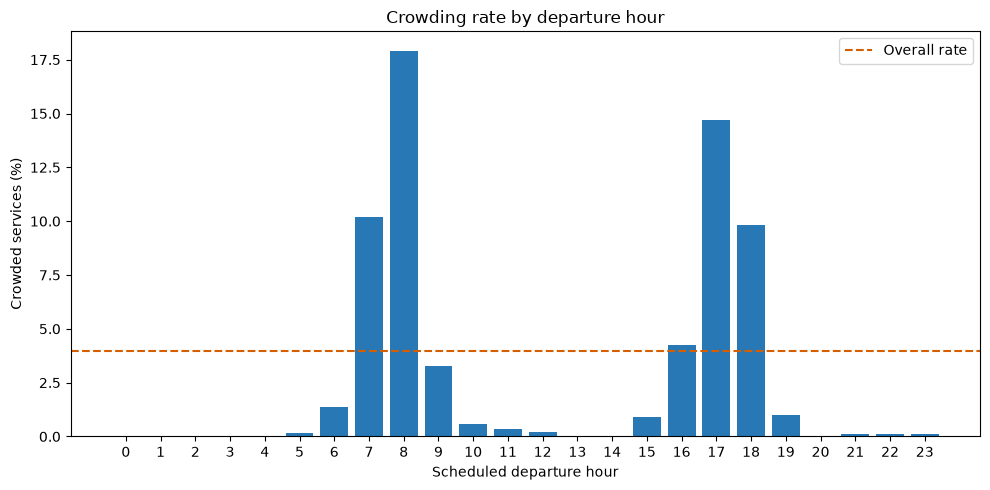

,Departure_Hour,Records,Crowding_Rate
8,8,3270,0.179205
17,17,3169,0.147050
7,7,2956,0.102165
18,18,3048,0.098425
16,16,2869,0.042524


In [33]:
hourly_summary = (
    eda_df.groupby("Departure_Hour")
    .agg(Records=("Crowded", "size"), Crowding_Rate=("Crowded", "mean"))
    .reset_index()
    .sort_values("Departure_Hour")
)

plt.figure(figsize=(10, 5))
plt.bar(hourly_summary["Departure_Hour"], hourly_summary["Crowding_Rate"] * 100, color="#2878B5")
plt.axhline(overall_crowding_rate * 100, color="#D55E00", linestyle="--", label="Overall rate")
plt.xticks(range(24))
plt.xlabel("Scheduled departure hour")
plt.ylabel("Crowded services (%)")
plt.title("Crowding rate by departure hour")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_crowding_by_departure_hour.png", dpi=200)
plt.show()

hourly_summary.sort_values("Crowding_Rate", ascending=False).head(5)


**interpretation:** The results identify the morning(7am-8am) and afternoon(4pm-6pm) commuter peaks as the priority periods for operational review. If the elevated rates are stable in a larger sample, the team should first investigate whether additional capacity, altered stopping patterns, or passenger-information measures are feasible in these hours rather than distributing effort evenly across the day.


### 2 - Which stop stations have the highest crowding risk?

Among stations with at least 100 observations, which stops have the highest proportion of crowded services?

A minimum of 100 records avoids treating a high percentage from a very small sample as a priority. The result can direct station-specific capacity and passenger-flow investigation.


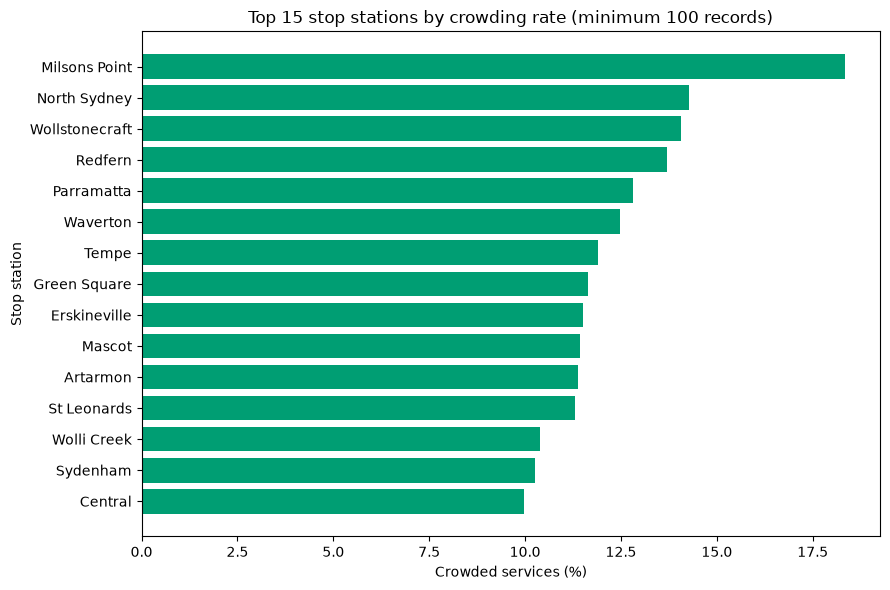

,Actual.Stop.Station,Records,Crowding_Rate
171,Milsons Point,409,0.183374
194,North Sydney,420,0.142857
293,Wollstonecraft,384,0.140625
218,Redfern,1518,0.137022
203,Parramatta,390,0.128205
281,Waverton,353,0.124646
255,Tempe,168,0.119048
103,Green Square,301,0.116279
90,Erskineville,165,0.115152
164,Mascot,306,0.114379


In [34]:
MIN_RECORDS = 100
station_summary = (
    eda_df.groupby("Actual.Stop.Station")
    .agg(Records=("Crowded", "size"), Crowding_Rate=("Crowded", "mean"))
    .reset_index()
)
top_stations = (
    station_summary[station_summary["Records"] >= MIN_RECORDS]
    .sort_values("Crowding_Rate", ascending=False)
    .head(15)
    .sort_values("Crowding_Rate")
)

plt.figure(figsize=(9, 6))
plt.barh(top_stations["Actual.Stop.Station"], top_stations["Crowding_Rate"] * 100, color="#009E73")
plt.xlabel("Crowded services (%)")
plt.ylabel("Stop station")
plt.title("Top 15 stop stations by crowding rate (minimum 100 records)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_crowding_by_station.png", dpi=200)
plt.show()

top_stations.sort_values("Crowding_Rate", ascending=False)


The highest-ranked stations are candidates for targeted investigation, such as checking whether crowding is concentrated on particular services or peak periods. These results do not prove that a station causes crowding; they identify where the operations team should inspect service capacity and passenger demand first.


### 3 - Which service line-direction combinations need attention?

Which service line and direction combinations have the highest crowding rate, after excluding groups with fewer than 100 records?

Capacity decisions are generally made for a corridor and direction, not for a station in isolation. This analysis helps distinguish a local station issue from a broader directional-service pattern.


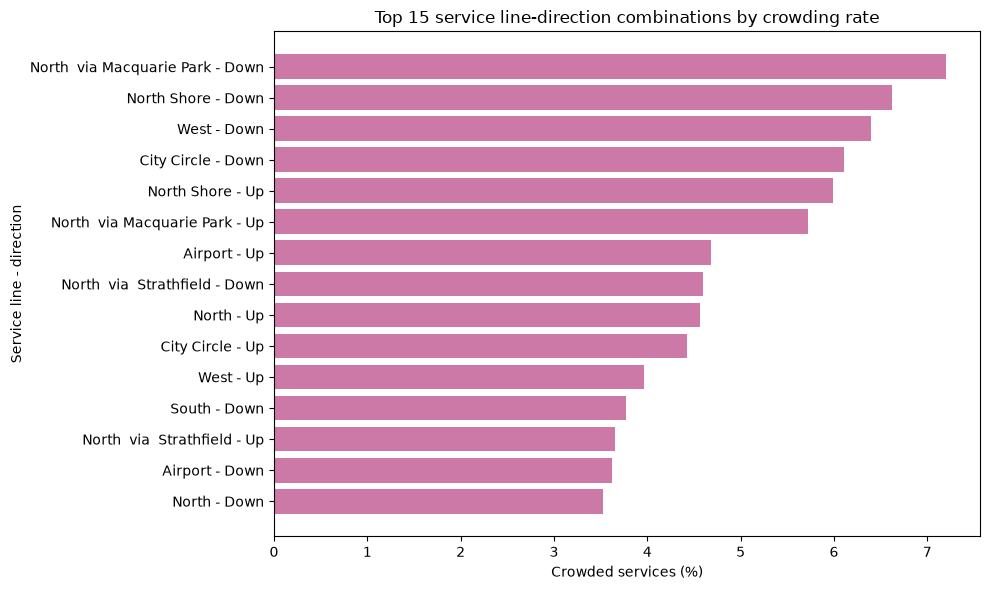

,Service.Line,Segment.Direction,Records,Crowding_Rate,Line_Direction
35,North via Macquarie Park,Down,1513,0.072042,North via Macquarie Park - Down
39,North Shore,Down,2477,0.066209,North Shore - Down
49,West,Down,3207,0.063923,West - Down
11,City Circle,Down,1311,0.061022,City Circle - Down
40,North Shore,Up,2304,0.059896,North Shore - Up
36,North via Macquarie Park,Up,1572,0.057252,North via Macquarie Park - Up
3,Airport,Up,2287,0.046786,Airport - Up
33,North via Strathfield,Down,913,0.046002,North via Strathfield - Down
32,North,Up,1336,0.045659,North - Up
12,City Circle,Up,1855,0.044205,City Circle - Up


In [35]:
line_summary = (
    eda_df.groupby(["Service.Line", "Segment.Direction"])
    .agg(Records=("Crowded", "size"), Crowding_Rate=("Crowded", "mean"))
    .reset_index()
)
top_lines = (
    line_summary[line_summary["Records"] >= MIN_RECORDS]
    .assign(Line_Direction=lambda x: x["Service.Line"] + " - " + x["Segment.Direction"])
    .sort_values("Crowding_Rate", ascending=False)
    .head(15)
    .sort_values("Crowding_Rate")
)

plt.figure(figsize=(10, 6))
plt.barh(top_lines["Line_Direction"], top_lines["Crowding_Rate"] * 100, color="#CC79A7")
plt.xlabel("Crowded services (%)")
plt.ylabel("Service line - direction")
plt.title("Top 15 service line-direction combinations by crowding rate")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_crowding_by_line_direction.png", dpi=200)
plt.show()

top_lines.sort_values("Crowding_Rate", ascending=False)


The leading line-direction combinations should be considered before lower-risk corridors when the operations team prioritises a detailed capacity review. The next check should separate peak and off-peak observations within each shortlisted corridor, because an overall line-level rate can conceal a concentrated peak-period problem.


### Assignment 2 recommendation, limitations, and hypotheses

**Proposed outcome:** predict `Crowded` (whether occupancy is `FEW_SEATS_AVAILABLE` or `STANDING_ROOM_ONLY`) at a stop. This binary outcome matches the operational question of limited seating.

**Candidate features available before or at the decision point:** scheduled departure-time band, departure hour, stop station, service line, segment direction, origin station, destination station, train set type, and station sequence order. `Occupancy Range` should not be used as a predictor because it is closely related to the occupancy outcome and would risk target leakage. Actual arrival/departure times should be used cautiously because they may not be known when an advance operational decision is made.

**Suitable modelling direction:** begin with an interpretable baseline classifier, such as logistic regression or a shallow decision tree, then compare it with another simple classifier in Assignment 2. The data are strongly imbalanced, so evaluation should include precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

**Important limitations and risks:** this dataset covers only a short January observation period, so findings may not generalise to other weeks, seasons, disruptions, or special events. Some categorical fields remain missing, and crowding is rare. Analyses are observational: a high station or line-level crowding rate does not establish the cause.

**Hypotheses to investigate in Assignment 2:** crowding is more likely during the morning and afternoon peaks; crowding differs by station and line-direction after controlling for departure time; and high-risk corridors may be driven by a small number of station-time combinations rather than all services on that line.
